In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


In [2]:
data=pd.read_csv('C:\mechine_learning\housing.csv')
print(data.head())
print(data.info())
print(data.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.shape

(20640, 10)

In [5]:
data=data.dropna() 

In [6]:
x =data[["median_income", "longitude", "latitude", "housing_median_age", "population"]]
y = data["median_house_value"]
m=len(y)
# y=y.values.reshape(-1,1)  #(1,-1)

| Rank | Feature              | Description          | Reason for Trend                                   |
| ---- | -------------------- | -------------------- | -------------------------------------------------- |
| 1️⃣  | `median_income`      | Avg income per block | Strong positive correlation with house price       |
| 2️⃣  | `longitude`          | East–West location   | Houses near coast (longitude ~ -122) are expensive |
| 3️⃣  | `latitude`           | North–South location | Prices drop inland (higher latitude)               |
| 4️⃣  | `housing_median_age` | Age of houses        | Moderate correlation (older = cheaper)             |
| 5️⃣  | `population`         | Area density         | Weak–moderate negative correlation                 |


In [7]:
print(x.shape)
print(y.shape)

(20433, 5)
(20433,)


In [8]:
# ---------- 3. FEATURE NORMALIZATION ----------
# Important for gradient descent to converge properly
mu = x.mean(axis=0)
sigma = x.std(axis=0)
X_norm = (x - mu) / sigma


In [9]:
# X_norm(20433, 5)
# ---------- 4. ADD BIAS COLUMN ----------
X_b = np.c_[np.ones((m, 1)), X_norm]   # shape (m, 6)
print(X_b.shape)  # (20433, 6)


(20433, 6)


In [10]:
# ---------- 5. NORMAL EQUATION ----------
theta_ne = np.linalg.pinv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print("\nTheta (Normal Equation):\n", theta_ne)


Theta (Normal Equation):
 [206864.41315519  71895.36706177 -90403.07370022 -94818.25795522
  11708.40228759  -1093.1943171 ]


In [11]:
# ---------- 6. COST FUNCTION----------
def compute_cost(X, y, theta):
    m = len(y)
    return (1/(2*m)) * np.sum((X.dot(theta) - y)**2)

In [12]:
def gradient_descent(X, y, alpha, iterations):
    m = len(y)
    theta = np.zeros(X.shape[1])
    cost_history = []

    for i in range(iterations):
        gradient = (1/m) * X.T.dot(X.dot(theta) - y)
        theta -= alpha * gradient
        cost_history.append(compute_cost(X, y, theta))
    return theta, cost_history


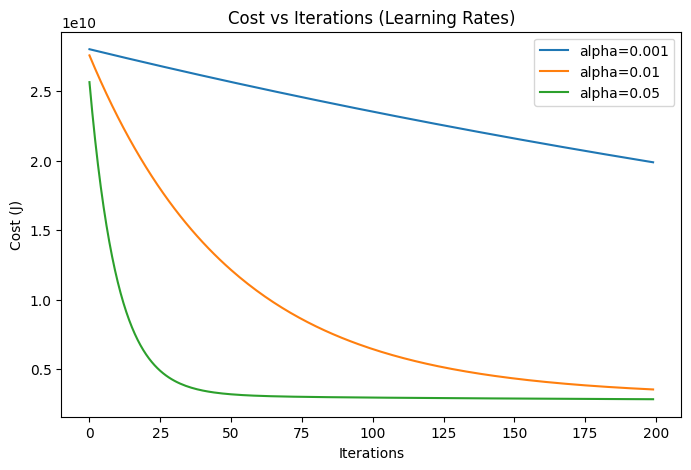

In [13]:
# ---------- 7. TEST DIFFERENT LEARNING RATES ----------
alphas = [0.001, 0.01, 0.05]
plt.figure(figsize=(8,5))
for a in alphas:
    theta_gd, cost = gradient_descent(X_b, y, a, 200)
    plt.plot(cost, label=f'alpha={a}')
plt.xlabel("Iterations")
plt.ylabel("Cost (J)")
plt.title("Cost vs Iterations (Learning Rates)")
plt.legend()
plt.show()

In [14]:
# ---------- 8. FINAL MODEL COMPARISON ----------
theta_gd, cost = gradient_descent(X_b, y, 0.01, 400)
print("\nTheta (Gradient Descent):\n", theta_gd)

y_pred_ne = X_b.dot(theta_ne)
y_pred_gd = X_b.dot(theta_gd)

mse_ne = np.mean((y - y_pred_ne)**2)
mse_gd = np.mean((y - y_pred_gd)**2)
print(f"\nMSE (Normal Equation): {mse_ne:.2f}")
print(f"MSE (Gradient Descent): {mse_gd:.2f}")



Theta (Gradient Descent):
 [203151.08248614  77965.8191807  -23198.63154367 -27666.70469298
  19062.40781834   1188.56953136]

MSE (Normal Equation): 5408335994.49
MSE (Gradient Descent): 6001692463.29



Theta (Gradient Descent):
 [203151.08248614  77965.8191807  -23198.63154367 -27666.70469298
  19062.40781834   1188.56953136]

MSE (Normal Equation): 5408335994.49
MSE (Gradient Descent): 6001692463.29


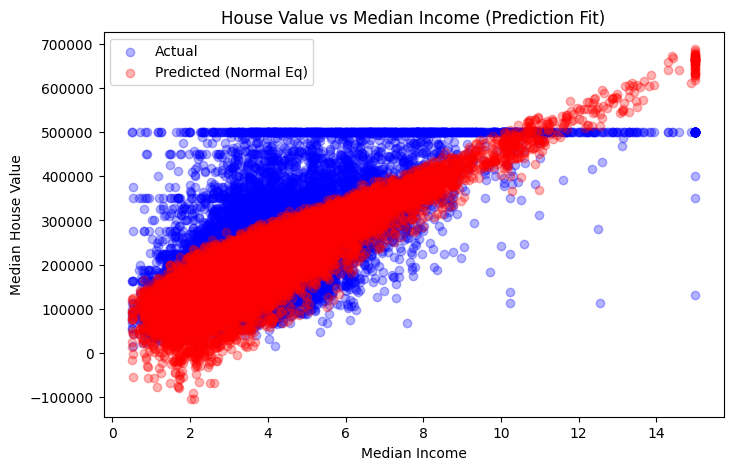

In [15]:
# ---------- 8. FINAL MODEL COMPARISON ----------
theta_gd, cost = gradient_descent(X_b, y, 0.01, 400)
print("\nTheta (Gradient Descent):\n", theta_gd)

y_pred_ne = X_b.dot(theta_ne)
y_pred_gd = X_b.dot(theta_gd)

mse_ne = np.mean((y - y_pred_ne)**2)
mse_gd = np.mean((y - y_pred_gd)**2)
print(f"\nMSE (Normal Equation): {mse_ne:.2f}")
print(f"MSE (Gradient Descent): {mse_gd:.2f}")

# ---------- 9. VISUALIZATION ----------
plt.figure(figsize=(8,5))
plt.scatter(data["median_income"], y, color='blue', alpha=0.3, label="Actual")
plt.scatter(data["median_income"], y_pred_ne, color='red', alpha=0.3, label="Predicted (Normal Eq)")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("House Value vs Median Income (Prediction Fit)")
plt.legend()
plt.show()


Theta (Gradient Descent):
 [203151.08248614  77965.8191807  -23198.63154367 -27666.70469298
  19062.40781834   1188.56953136]

MSE (Normal Equation): 5408335994.49
MSE (Gradient Descent): 6001692463.29


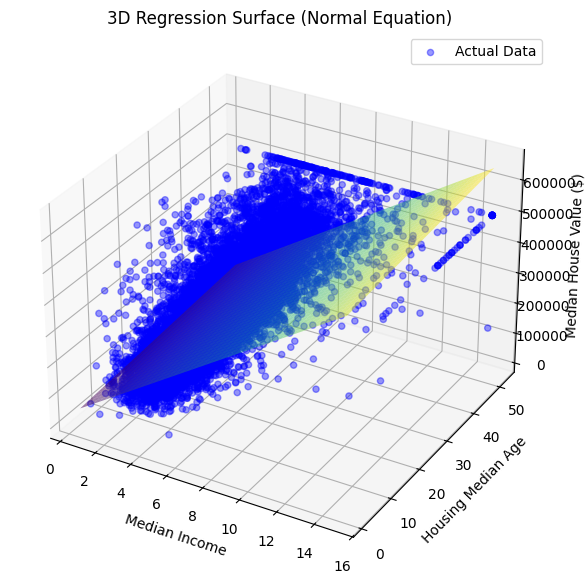

In [16]:
# ---------- 8. FINAL MODEL COMPARISON ----------
theta_gd, cost = gradient_descent(X_b, y, 0.01, 400)
print("\nTheta (Gradient Descent):\n", theta_gd)

y_pred_ne = X_b.dot(theta_ne)
y_pred_gd = X_b.dot(theta_gd)

mse_ne = np.mean((y - y_pred_ne)**2)
mse_gd = np.mean((y - y_pred_gd)**2)
print(f"\nMSE (Normal Equation): {mse_ne:.2f}")
print(f"MSE (Gradient Descent): {mse_gd:.2f}")

# ---------- 9. 3D VISUALIZATION ----------
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Convert X to NumPy array (important fix)
if isinstance(x, pd.DataFrame):
    X = x.values

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Select two main input features for visualization
x1 = data["median_income"]
x2 = data["housing_median_age"]
y_true = y
y_pred = y_pred_ne  # use Normal Equation predictions for surface

# Create grid (mesh) for surface
x1_range = np.linspace(x1.min(), x1.max(), 40)
x2_range = np.linspace(x2.min(), x2.max(), 40)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Compute mean/std for normalization (use from training X array)
mu_1, sigma_1 = X[:, 0].mean(), X[:, 0].std()  # median_income
mu_2, sigma_2 = X[:, 3].mean(), X[:, 3].std()  # housing_median_age

# Normalize grid
X1_norm = (X1 - mu_1) / sigma_1
X2_norm = (X2 - mu_2) / sigma_2

# Keep other features at mean
mu_full = X.mean(axis=0)
sigma_full = X.std(axis=0)
other_feats = (mu_full - mu_full) / sigma_full  # → 0 after normalization

# Compute regression plane (Z = θ0 + θ1*x1 + θ2*x2 + ...)
Z = (
    theta_ne[0]
    + theta_ne[1]*X1_norm            # median_income
    + theta_ne[4]*X2_norm            # housing_median_age
    + theta_ne[2]*0                  # longitude mean
    + theta_ne[3]*0                  # latitude mean
    + theta_ne[5]*0                  # population mean
)

# Plot actual points
ax.scatter(x1, x2, y_true, color='blue', alpha=0.4, label='Actual Data')

# Plot regression surface
ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.5, edgecolor='none')

ax.set_xlabel("Median Income")
ax.set_ylabel("Housing Median Age")
ax.set_zlabel("Median House Value ($)")
ax.set_title("3D Regression Surface (Normal Equation)")
plt.legend()
plt.show()
